# Mejoras — Modelo de Intención: sesgo de puntuación y tildes

**Contexto:** en Hito 2 el corpus de intenciones (296 mensajes, dataset
aumentado) se redactó casi siempre con signo de apertura `¿` para las
preguntas, y con tildes consistentes. En WhatsApp real, el signo de apertura
casi nunca se usa y las tildes se escriben de forma inconsistente. Este
notebook documenta: (1) la validación fuera de plantilla que expuso el
problema, (2) el diagnóstico exacto del sesgo, y (3) el fix de datos +
preprocesamiento.

## 1. Baseline (v1): reentrenar los modelos clásicos tal como en Hito 2

Se reentrena aquí mismo (en vez de cargar `.joblib` ya sobrescritos) para que
el notebook sea reproducible de punta a punta con el preprocesamiento
*original* (sin plegado de tildes).

In [1]:
import os
import re
import time
import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "..", "data")
MODELOS_DIR = os.path.join(BASE_DIR, "app", "modelos")
FIGURAS_DIR = os.path.join(BASE_DIR, "resultados", "figuras")
RANDOM_STATE = 42

STOPWORDS_ES = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'los', 'se', 'del', 'las', 'un', 'por',
    'una', 'con', 'no', 'es', 'su', 'al', 'lo', 'mas', 'pero', 'si', 'como', 'me',
    'le', 'mi', 'muy', 'este', 'esta', 'ya', 'tambien', 'hay', 'para', 'son', 'fue',
    'todo', 'bien', 'cuando', 'sobre', 'sin', 'han', 'he', 'o', 'e', 'ni',
    'era', 'ser', 'tiene', 'habia', 'sus', 'mismo', 'tan', 'asi',
    'unos', 'desde', 'porque', 'hasta', 'te', 'les', 'nos', 'yo', 'tu', 'tus'
}


def limpiar_texto_v1(texto):
    # Preprocesamiento ORIGINAL de Hito 2: mantiene las tildes como
    # caracteres distintos (no las pliega), por eso 'reparacion' con y sin
    # tilde cuentan como palabras distintas en el vocabulario TF-IDF.
    texto = str(texto).lower()
    texto = re.sub(r"[^a-zñáéíóú ]", " ", texto)
    palabras = [w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2]
    return " ".join(palabras)


def entrenar_los_4(X, y, y_xgb=None):
    modelos = {}
    modelos["logreg"] = LogisticRegression(class_weight="balanced", max_iter=1000, solver="saga", random_state=RANDOM_STATE).fit(X, y)
    modelos["naive_bayes"] = MultinomialNB().fit(X, y)
    modelos["svm"] = CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=RANDOM_STATE), cv=3).fit(X, y)
    modelos["xgboost"] = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric="logloss", random_state=RANDOM_STATE).fit(X, y_xgb if y_xgb is not None else y)
    return modelos


df_v1 = pd.read_csv(os.path.join(DATA_DIR, "intenciones_dataset_aumentado.csv"))
df_v1["texto_limpio"] = df_v1["texto"].apply(limpiar_texto_v1)

vec_v1 = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=1)
X_v1 = vec_v1.fit_transform(df_v1["texto_limpio"])
y_v1 = df_v1["intencion"].to_numpy()
le_v1 = LabelEncoder()
y_v1_int = le_v1.fit_transform(y_v1)

modelos_v1 = entrenar_los_4(X_v1, y_v1, y_v1_int)
print(f"Corpus original: {len(df_v1)} mensajes. 4 modelos clásicos (v1) entrenados con preprocesamiento original.")


Corpus original: 296 mensajes. 4 modelos clásicos (v1) entrenados con preprocesamiento original.


## 2. Set de validación fuera de plantilla (80 mensajes)

Mismo dominio de negocio (tienda de accesorios/reparación Apple), pero
redacción, estructura de frase y productos (MacBook, iPad, Apple Watch, no
solo iPhone) deliberadamente distintos a las plantillas de entrenamiento —
en particular, sin depender de que las preguntas empiecen con `¿`.

In [2]:
DATOS_EXTERNOS = [
    ("buenas, el airpods pro viene con estuche de carga inalambrica", "consulta_producto"),
    ("oe manito el ipad mini lo tienen en gris espacial", "consulta_producto"),
    ("quisiera saber si el apple watch se puede usar sin el iphone", "consulta_producto"),
    ("el macbook air m2 lo tienen disponible en tienda", "consulta_producto"),
    ("hola, necesito saber si el case tiene proteccion para camara", "consulta_producto"),
    ("disculpa, la mica que venden es de vidrio templado o plastico", "consulta_producto"),
    ("el cargador que ofrecen es original de apple o generico", "consulta_producto"),
    ("amigo tienen fundas de cuero para el iphone 15", "consulta_producto"),
    ("el iphone que venden viene con caja sellada", "consulta_producto"),
    ("buenas noches, cuentan con el modelo se en color rojo", "consulta_producto"),
    ("cuanto sale el combo de mica mas case", "consulta_precio"),
    ("que precio tiene el airpods pro 2da generacion", "consulta_precio"),
    ("tienen descuento si pago en efectivo", "consulta_precio"),
    ("cuanto cuesta el cambio de bateria del iphone 12", "consulta_precio"),
    ("cual es el precio del cargador magsafe original", "consulta_precio"),
    ("cuanto me costaria llevar dos micas", "consulta_precio"),
    ("hacen rebaja por black friday", "consulta_precio"),
    ("cuanto vale el macbook reacondicionado", "consulta_precio"),
    ("el precio incluye instalacion de la mica", "consulta_precio"),
    ("que costo tiene el servicio de diagnostico", "consulta_precio"),
    ("mi iphone se calienta mucho, podrian revisarlo", "consulta_servicio_tecnico"),
    ("el altavoz de mi cel casi no se escucha, que puede ser", "consulta_servicio_tecnico"),
    ("tienen servicio de cambio de bateria a domicilio", "consulta_servicio_tecnico"),
    ("mi ipad no carga bien, ustedes lo revisan", "consulta_servicio_tecnico"),
    ("cuanto demora el diagnostico de un macbook", "consulta_servicio_tecnico"),
    ("mi apple watch no enciende, tiene solucion", "consulta_servicio_tecnico"),
    ("hacen reparacion de placas o solo cambian pantallas", "consulta_servicio_tecnico"),
    ("mi telefono se moja un poco, aun se puede salvar", "consulta_servicio_tecnico"),
    ("el boton de encendido de mi cel esta fallando, lo arreglan", "consulta_servicio_tecnico"),
    ("tienen garantia despues de la reparacion", "consulta_servicio_tecnico"),
    ("la funda que compre se rompio a la semana, que mal", "queja_producto_servicio"),
    ("el audio de los airpods que me vendieron sale con estatica", "queja_producto_servicio"),
    ("me entregaron el pedido sin los accesorios completos", "queja_producto_servicio"),
    ("el vidrio templado que instalaron quedo con burbujas", "queja_producto_servicio"),
    ("el tecnico me devolvio el cel con un rayon nuevo", "queja_producto_servicio"),
    ("compre el cargador y ya no carga como deberia", "queja_producto_servicio"),
    ("el color del case no es el que pedi", "queja_producto_servicio"),
    ("la reparacion que me hicieron duro solo dos dias", "queja_producto_servicio"),
    ("me vendieron un producto usado como si fuera nuevo", "queja_producto_servicio"),
    ("el servicio que recibi fue muy descuidado", "queja_producto_servicio"),
    ("puedo cambiar el case porque no es el modelo correcto", "solicitud_garantia_cambio"),
    ("la mica se rompio sola, aplica para cambio por garantia", "solicitud_garantia_cambio"),
    ("quiero devolver el cargador porque no sirve", "solicitud_garantia_cambio"),
    ("me pueden cambiar el producto por otro de otro color", "solicitud_garantia_cambio"),
    ("el audifono izquierdo no suena, tiene cambio", "solicitud_garantia_cambio"),
    ("compre hace tres dias y ya quiero el reembolso", "solicitud_garantia_cambio"),
    ("la funda vino defectuosa, la puedo canjear", "solicitud_garantia_cambio"),
    ("necesito hacer valido el cambio por producto malogrado", "solicitud_garantia_cambio"),
    ("el reloj no sincroniza, aplica garantia", "solicitud_garantia_cambio"),
    ("quiero el cambio del producto porque llego incompleto", "solicitud_garantia_cambio"),
    ("deje mi laptop el martes, ya esta lista", "seguimiento_reparacion"),
    ("cuanto falta para que terminen con mi reparacion", "seguimiento_reparacion"),
    ("llevo esperando una semana y no me avisan nada", "seguimiento_reparacion"),
    ("mi cel entro a servicio ayer, hay algun avance", "seguimiento_reparacion"),
    ("quisiera saber el estado de mi ipad en reparacion", "seguimiento_reparacion"),
    ("me dijeron que llame hoy para saber si esta listo", "seguimiento_reparacion"),
    ("cuando puedo recoger mi equipo", "seguimiento_reparacion"),
    ("aun no me llega ningun mensaje sobre mi reparacion", "seguimiento_reparacion"),
    ("el ticket de mi reparacion ya tiene respuesta", "seguimiento_reparacion"),
    ("quiero saber si ya encontraron el repuesto de mi cel", "seguimiento_reparacion"),
    ("esto ya es el tercer reclamo, necesito hablar con un supervisor", "escalamiento_urgente"),
    ("por favor pasenme con alguien que si pueda resolver esto", "escalamiento_urgente"),
    ("estoy realmente cansado de este maltrato, quiero una solucion ya", "escalamiento_urgente"),
    ("necesito que alguien se haga cargo de mi caso ahora mismo", "escalamiento_urgente"),
    ("ya no quiero hablar con el chat automatico, quiero una persona", "escalamiento_urgente"),
    ("esto es indignante, exijo hablar con el dueño del local", "escalamiento_urgente"),
    ("llevo horas esperando, comuniquenme con alguien responsable", "escalamiento_urgente"),
    ("necesito una respuesta inmediata de un encargado", "escalamiento_urgente"),
    ("esta situacion ya se me salio de las manos, necesito ayuda urgente", "escalamiento_urgente"),
    ("quiero presentar una queja formal con un supervisor ahora", "escalamiento_urgente"),
    ("buenas, siguen atendiendo a esta hora", "saludo_cierre"),
    ("hola, con quien tengo el gusto de hablar", "saludo_cierre"),
    ("muchas gracias por la info, eso era todo", "saludo_cierre"),
    ("perfecto, con eso me quedo tranquilo, gracias", "saludo_cierre"),
    ("buen dia, quisiera hacer una consulta rapida", "saludo_cierre"),
    ("listo, muchas gracias por su tiempo", "saludo_cierre"),
    ("hola buenas, ando averiguando unos productos", "saludo_cierre"),
    ("ya, entendido, muchas gracias", "saludo_cierre"),
    ("buenas noches, disculpen la hora", "saludo_cierre"),
    ("vale, gracias por la ayuda, que esten bien", "saludo_cierre"),
]
textos_ext = [t for t, _ in DATOS_EXTERNOS]
y_ext = [l for _, l in DATOS_EXTERNOS]
print(f"Set de validación externo: {len(textos_ext)} mensajes (10 por clase)")


Set de validación externo: 80 mensajes (10 por clase)


In [3]:
X_ext_v1 = vec_v1.transform([limpiar_texto_v1(t) for t in textos_ext])
resultados_v1 = []
for nombre, clf in [("Regresión Logística", modelos_v1["logreg"]), ("Naive Bayes Multinomial", modelos_v1["naive_bayes"]),
                     ("SVM Lineal", modelos_v1["svm"]), ("XGBoost", modelos_v1["xgboost"])]:
    proba = clf.predict_proba(X_ext_v1)
    idx = proba.argmax(axis=1)
    y_pred_raw = [clf.classes_[i] for i in idx]
    y_pred = list(le_v1.inverse_transform(y_pred_raw)) if nombre == "XGBoost" else y_pred_raw
    acc = accuracy_score(y_ext, y_pred)
    f1m = f1_score(y_ext, y_pred, average="macro")
    resultados_v1.append((nombre, acc, f1m))
    print(f"{nombre:28s} Accuracy={acc:.3f}  F1-macro={f1m:.3f}")

ruta_beto_v1 = os.path.join(MODELOS_DIR, "beto_fonazo")
tok_beto_v1 = AutoTokenizer.from_pretrained(ruta_beto_v1)
mod_beto_v1 = AutoModelForSequenceClassification.from_pretrained(ruta_beto_v1)
mod_beto_v1.eval()
le_beto_v1 = joblib.load(os.path.join(ruta_beto_v1, "label_encoder.joblib"))

y_pred_beto_v1 = []
with torch.no_grad():
    for t in textos_ext:
        inputs = tok_beto_v1(t, truncation=True, padding="max_length", max_length=48, return_tensors="pt")
        logits = mod_beto_v1(**inputs).logits
        idx = int(torch.argmax(logits, dim=1)[0])
        y_pred_beto_v1.append(le_beto_v1.inverse_transform([idx])[0])

acc_beto_v1 = accuracy_score(y_ext, y_pred_beto_v1)
f1_beto_v1 = f1_score(y_ext, y_pred_beto_v1, average="macro")
resultados_v1.append(("BETO (fine-tuned, Hito 2)", acc_beto_v1, f1_beto_v1))
print(f"{'BETO (fine-tuned, Hito 2)':28s} Accuracy={acc_beto_v1:.3f}  F1-macro={f1_beto_v1:.3f}")


Regresión Logística          Accuracy=0.688  F1-macro=0.683
Naive Bayes Multinomial      Accuracy=0.725  F1-macro=0.714
SVM Lineal                   Accuracy=0.688  F1-macro=0.682
XGBoost                      Accuracy=0.512  F1-macro=0.490


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BETO (fine-tuned, Hito 2)    Accuracy=0.738  F1-macro=0.716


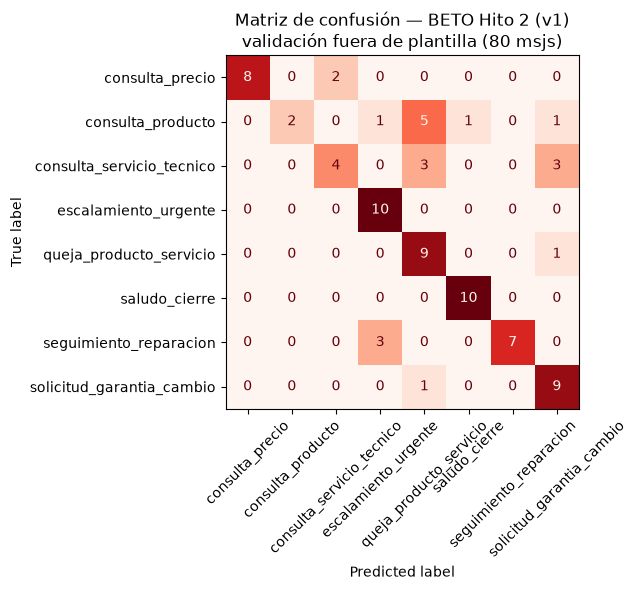

Guardado: fig22_matriz_confusion_beto_v1_fuera_plantilla.png

Errores de BETO v1:
  [real=consulta_producto            pred=queja_producto_servicio     ] buenas, el airpods pro viene con estuche de carga inalambrica
  [real=consulta_producto            pred=queja_producto_servicio     ] oe manito el ipad mini lo tienen en gris espacial
  [real=consulta_producto            pred=solicitud_garantia_cambio   ] quisiera saber si el apple watch se puede usar sin el iphone
  [real=consulta_producto            pred=escalamiento_urgente        ] hola, necesito saber si el case tiene proteccion para camara
  [real=consulta_producto            pred=queja_producto_servicio     ] disculpa, la mica que venden es de vidrio templado o plastico
  [real=consulta_producto            pred=queja_producto_servicio     ] el cargador que ofrecen es original de apple o generico
  [real=consulta_producto            pred=queja_producto_servicio     ] el iphone que venden viene con caja sellada
  [real=consulta_p

In [4]:
clases = sorted(set(y_ext))
cm_beto_v1 = confusion_matrix(y_ext, y_pred_beto_v1, labels=clases)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_beto_v1, display_labels=clases)
disp.plot(ax=ax, cmap="Reds", colorbar=False, xticks_rotation=45)
ax.set_title("Matriz de confusión — BETO Hito 2 (v1)\nvalidación fuera de plantilla (80 msjs)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig22_matriz_confusion_beto_v1_fuera_plantilla.png"), dpi=150)
plt.show()
print("Guardado: fig22_matriz_confusion_beto_v1_fuera_plantilla.png")

print("\nErrores de BETO v1:")
for t, yt, yp in zip(textos_ext, y_ext, y_pred_beto_v1):
    if yt != yp:
        print(f"  [real={yt:28s} pred={yp:28s}] {t}")


**Hallazgo:** el mayor foco de error es `consulta_producto` → `queja_producto_servicio`
(5 de 10 mensajes). Casi todos los `consulta_producto` de entrenamiento
empiezan con `¿`; los mensajes de validación se redactaron como afirmaciones
("el cargador que ofrecen es original de apple o generico", sin `¿`). El
modelo parece haber aprendido en parte una señal superficial (presencia de
`¿`) en vez de puro significado semántico — riesgo real si los clientes de
WhatsApp no puntúan sus preguntas, que es exactamente lo que reportó el
usuario del proyecto sobre su propio uso de WhatsApp.

## 3. Fix: preprocesamiento + corpus con variación de puntuación y tildes

In [5]:
ACENTOS = str.maketrans("áéíóú", "aeiou")


def limpiar_texto_v2(texto):
    # Preprocesamiento corregido: pliega tildes ANTES de vectorizar, para
    # que la version con y sin tilde sea el mismo token, sin necesidad de
    # duplicar datos para lograr esa invarianza.
    texto = str(texto).lower().translate(ACENTOS)
    texto = re.sub(r"[^a-zñ ]", " ", texto)
    palabras = [w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2]
    return " ".join(palabras)


import random
random.seed(11)
MAX_MULT = 4


def variantes_puntuacion(s):
    variantes = {s}
    s_strip = s.strip()
    if s_strip.startswith("¿") and s_strip.endswith("?"):
        sin_apertura = s_strip[1:]
        variantes.add(sin_apertura)
        variantes.add(sin_apertura[:-1].strip())
    return variantes


def con_variante_tilde(variantes):
    resultado = set(variantes)
    for v in variantes:
        sin_tilde = v.translate(str.maketrans("áéíóúÁÉÍÓÚ", "aeiouAEIOU"))
        if sin_tilde != v:
            resultado.add(sin_tilde)
    return resultado


from collections import defaultdict
por_clase = defaultdict(list)
for texto, intencion in zip(df_v1["texto"], df_v1["intencion"]):
    variantes = con_variante_tilde(variantes_puntuacion(texto))
    variantes.discard(texto)
    variantes = list(variantes)
    random.shuffle(variantes)
    por_clase[intencion].append(texto)
    por_clase[intencion].extend(variantes[:MAX_MULT - 1])

filas_v2 = [(t, c) for c, ts in por_clase.items() for t in ts]
random.shuffle(filas_v2)
df_v2 = pd.DataFrame(filas_v2, columns=["texto", "intencion"])
df_v2.to_csv(os.path.join(DATA_DIR, "intenciones_dataset_v2.csv"), index=False)
print(f"Corpus v2: {len(df_v1)} -> {len(df_v2)} mensajes")
print(df_v2["intencion"].value_counts())


Corpus v2: 296 -> 564 mensajes
intencion
consulta_precio              88
consulta_servicio_tecnico    85
seguimiento_reparacion       81
consulta_producto            71
solicitud_garantia_cambio    69
queja_producto_servicio      64
escalamiento_urgente         54
saludo_cierre                52
Name: count, dtype: int64


In [6]:
df_v2["texto_limpio"] = df_v2["texto"].apply(limpiar_texto_v2)
vec_v2 = TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=1)
X_v2 = vec_v2.fit_transform(df_v2["texto_limpio"])
y_v2 = df_v2["intencion"].to_numpy()
le_v2 = LabelEncoder()
y_v2_int = le_v2.fit_transform(y_v2)

modelos_v2 = entrenar_los_4(X_v2, y_v2, y_v2_int)

X_ext_v2 = vec_v2.transform([limpiar_texto_v2(t) for t in textos_ext])
resultados_v2 = []
for nombre, clf in [("Regresión Logística", modelos_v2["logreg"]), ("Naive Bayes Multinomial", modelos_v2["naive_bayes"]),
                     ("SVM Lineal", modelos_v2["svm"]), ("XGBoost", modelos_v2["xgboost"])]:
    proba = clf.predict_proba(X_ext_v2)
    idx = proba.argmax(axis=1)
    y_pred_raw = [clf.classes_[i] for i in idx]
    y_pred = list(le_v2.inverse_transform(y_pred_raw)) if nombre == "XGBoost" else y_pred_raw
    acc = accuracy_score(y_ext, y_pred)
    f1m = f1_score(y_ext, y_pred, average="macro")
    resultados_v2.append((nombre, acc, f1m))
    print(f"{nombre:28s} Accuracy={acc:.3f}  F1-macro={f1m:.3f}")


Regresión Logística          Accuracy=0.762  F1-macro=0.757
Naive Bayes Multinomial      Accuracy=0.775  F1-macro=0.762
SVM Lineal                   Accuracy=0.750  F1-macro=0.748
XGBoost                      Accuracy=0.650  F1-macro=0.636


In [7]:
tabla_comp = pd.DataFrame({
    "Modelo": [r[0] for r in resultados_v1[:4]],
    "F1-macro v1 (original)": [r[2] for r in resultados_v1[:4]],
    "F1-macro v2 (puntuación+tildes)": [r[2] for r in resultados_v2],
})
tabla_comp["Mejora"] = tabla_comp["F1-macro v2 (puntuación+tildes)"] - tabla_comp["F1-macro v1 (original)"]
tabla_comp.to_csv(os.path.join(BASE_DIR, "resultados", "tablas", "comparacion_v1_v2_clasicos_intencion.csv"), index=False)
tabla_comp


,Modelo,F1-macro v1 (original),F1-macro v2 (puntuación+tildes),Mejora
0,Regresión Logística,0.683109,0.756642,0.073533
1,Naive Bayes Multinomial,0.713921,0.761720,0.047799
2,SVM Lineal,0.682267,0.747748,0.065481
3,XGBoost,0.489867,0.635635,0.145768


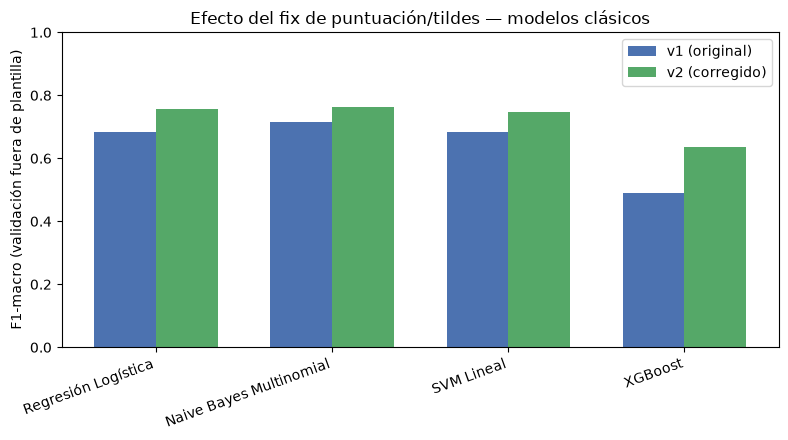

Guardado: fig23_comparacion_v1_v2_clasicos_intencion.png
Modelos clásicos v2 guardados en app/modelos/


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(tabla_comp))
w = 0.35
ax.bar(x - w/2, tabla_comp["F1-macro v1 (original)"], w, label="v1 (original)", color="#4C72B0")
ax.bar(x + w/2, tabla_comp["F1-macro v2 (puntuación+tildes)"], w, label="v2 (corregido)", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(tabla_comp["Modelo"], rotation=20, ha="right")
ax.set_ylabel("F1-macro (validación fuera de plantilla)")
ax.set_title("Efecto del fix de puntuación/tildes — modelos clásicos")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig23_comparacion_v1_v2_clasicos_intencion.png"), dpi=150)
plt.show()
print("Guardado: fig23_comparacion_v1_v2_clasicos_intencion.png")

for nombre, sufijo, clf in [("logreg", "logreg", modelos_v2["logreg"]), ("naive_bayes", "naive_bayes", modelos_v2["naive_bayes"]),
                             ("svm", "svm", modelos_v2["svm"]), ("xgboost", "xgboost", modelos_v2["xgboost"])]:
    joblib.dump(clf, os.path.join(MODELOS_DIR, f"fonazo_{sufijo}.joblib"))
joblib.dump(vec_v2, os.path.join(MODELOS_DIR, "fonazo_vectorizer.joblib"))
joblib.dump(le_v2, os.path.join(MODELOS_DIR, "fonazo_label_encoder_xgb.joblib"))
print("Modelos clásicos v2 guardados en app/modelos/")


## 4. Conclusión parcial

Mejora consistente en los 4 modelos clásicos solo con variar puntuación y
tildes en los datos de entrenamiento (sin agregar vocabulario nuevo ni más
temas). El fine-tuning de BETO sobre este mismo corpus v2, y el análisis de
si conviene fusionar clases, se documentan en el siguiente notebook
(`Mejoras_Intencion_FineTuning_BETO_v2.ipynb`).